# Analiza zbioru danych

Co jest w danych, zanim cokolwiek wytrenujemy. Trzy podzbiory: trening, walidacja i test.

Pula przeszla odsianie redundancji **natywnym** `cd-hit-est`, a nastepnie filtr przewagi sparowanych
(`paired_fraction >= 0.5`), kontrole poprawnosci i kontrole wykonalnych petli spinki. Ograniczenie
dlugosci do 200 nt naklada `src/cdhit.py`.

Kubelki raportowania sa **NARASTAJACE**: `<= 50 nt`, `<= 100 nt`, `<= 200 nt`. Wiersz `<= 100 nt`
zawiera w sobie wszystkie struktury krotsze niz 50 nt. Kazdy kubelek odpowiada na pytanie
"jak model radzi sobie na strukturach do tej dlugosci".

Caly kod rysujacy jest w tym notatniku — mozna go edytowac na miejscu.

In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120

# Kubelki NARASTAJACE: "<= 100 nt" zawiera w sobie "<= 50 nt".
KUBELKI = [50, 100, 200]


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym, po wszystkich sekwencjach."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


In [2]:
df = wczytaj()
spl = wczytaj_split("rodzinowy")
czesci = {z: df.iloc[spl[z]] for z in ("train", "val", "test")}
ZBIORY = ["train", "val", "test"]

print(f"zbior roboczy: {len(df)} struktur, {df.family.nunique()} rodzin")
for z, d in czesci.items():
    L = d.secondary_structure.str.len()
    print(f"  {z:6} {len(d):5}  rodzin {d.family.nunique():4}  mediana {int(L.median()):4} nt")

zbior roboczy: 3640 struktur, 324 rodzin
  train   2185  rodzin   82  mediana   78 nt
  val      727  rodzin  122  mediana   90 nt
  test     728  rodzin  120  mediana   93 nt


## 1. Dlugosc struktur

Lewy panel to rozklad, prawy — liczebnosc kubelkow raportowania. Kubelki sa narastajace, wiec
slupki NIE sumuja sie do calosci: kazdy pokazuje, ile struktur miesci sie do danej dlugosci.

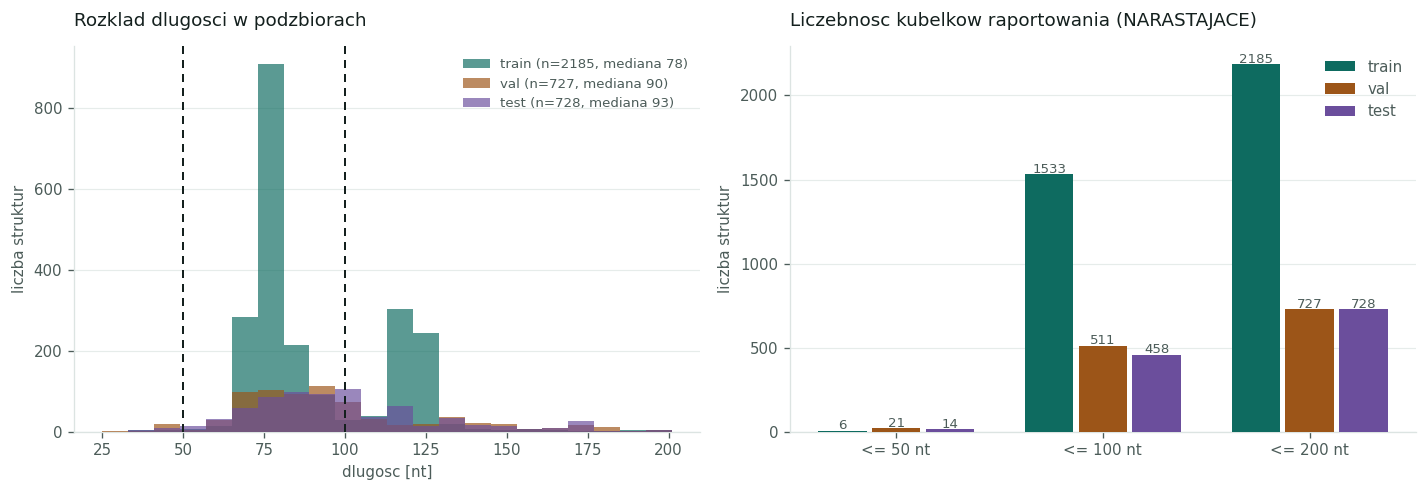

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))

for z, kol in zip(ZBIORY, (C1, C2, C3)):
    L = czesci[z].secondary_structure.str.len()
    axs[0].hist(L, bins=np.arange(25, 205, 8), alpha=0.68, color=kol, zorder=3,
                label=f"{z} (n={len(L)}, mediana {int(L.median())})")
for gr in KUBELKI[:-1]:
    axs[0].axvline(gr, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=4)
styl(axs[0], "Rozklad dlugosci w podzbiorach", "liczba struktur", "dlugosc [nt]")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)

x = np.arange(len(KUBELKI))
w = 0.26
for k, (z, kol) in enumerate(zip(ZBIORY, (C1, C2, C3))):
    L = czesci[z].secondary_structure.str.len()
    v = [int((L <= hi).sum()) for hi in KUBELKI]
    b = axs[1].bar(x + (k - 1) * w, v, w * 0.9, color=kol, label=z, zorder=3)
    for r, vv in zip(b, v):
        axs[1].text(r.get_x() + r.get_width() / 2, vv + 8, str(vv),
                    ha="center", fontsize=8, color=INK2)
axs[1].set_xticks(x)
axs[1].set_xticklabels([f"<= {hi} nt" for hi in KUBELKI], fontsize=9)
styl(axs[1], "Liczebnosc kubelkow raportowania (NARASTAJACE)", "liczba struktur")
axs[1].legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.tight_layout()

## 2. Rodziny Rfam

Podzial jest RODZINOWY: kazda rodzina trafia do dokladnie jednego podzbioru, wiec test sklada sie
z rodzin, ktorych model nie widzial ani razu.

Procenty to udzial w calym podzbiorze, a slupki sumuja sie do 100%. Osobno pokazujemy tylko rodziny
stanowiace **co najmniej 1%** zbioru (najwyzej szesc); cala reszta trafia do slupka "pozostale".

train  pokazane osobno: 2 rodzin =  92.2%,  pozostale 80 rodzin =   7.8%
val    pokazane osobno: 6 rodzin =  45.4%,  pozostale 116 rodzin =  54.6%
test   pokazane osobno: 6 rodzin =  33.0%,  pozostale 114 rodzin =  67.0%


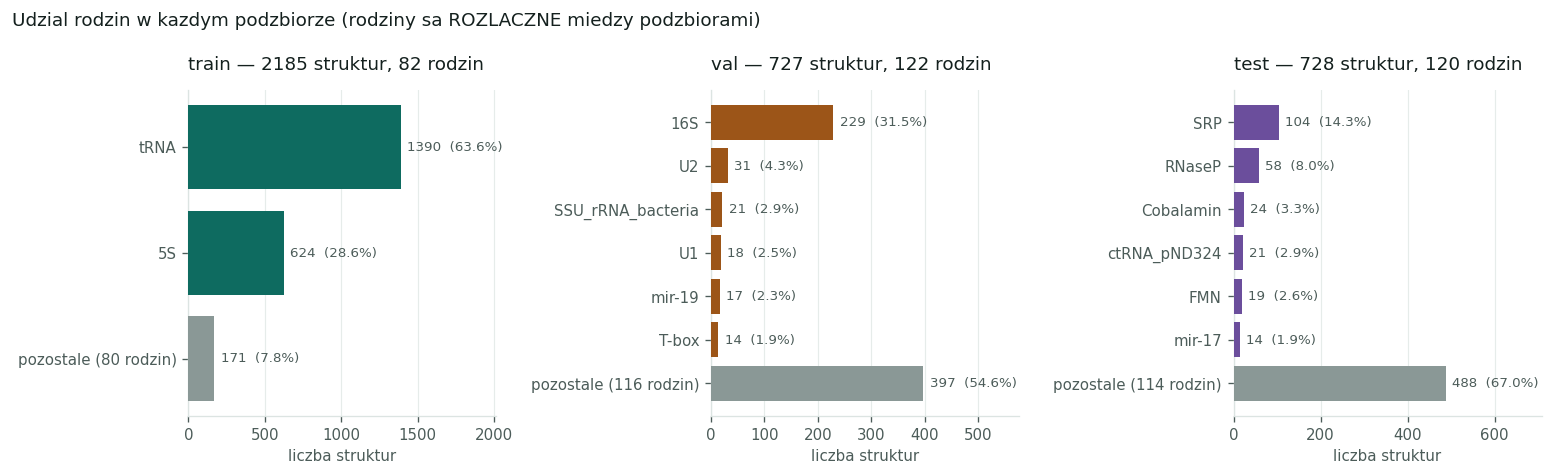

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.0))
PROG = 0.01          # rodziny ponizej 1% zbioru trafiaja do slupka zbiorczego

for ax, z, kol in zip(axs, ZBIORY, (C1, C2, C3)):
    d = czesci[z]
    vc = d.family.value_counts()
    duze = vc[vc / len(d) >= PROG].head(6)
    reszta = len(d) - duze.sum()
    n_reszta = d.family.nunique() - len(duze)

    etykiety = [f"pozostale ({n_reszta} rodzin)"] + list(duze.index)[::-1]
    wartosci = [reszta] + list(duze.values)[::-1]
    kolory = [C4] + [kol] * len(duze)

    ax.barh(range(len(wartosci)), wartosci, color=kolory, zorder=3)
    for i, v in enumerate(wartosci):
        ax.text(v + max(wartosci) * 0.03, i, f"{v}  ({v / len(d) * 100:.1f}%)",
                va="center", fontsize=8, color=INK2)
    ax.set_yticks(range(len(etykiety)))
    ax.set_yticklabels(etykiety, fontsize=8)
    ax.set_xlim(0, max(wartosci) * 1.45)
    styl(ax, f"{z} — {len(d)} struktur, {d.family.nunique()} rodzin", "", "liczba struktur")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", color=SIATKA, lw=0.7, alpha=0.7)
fig.suptitle("Udzial rodzin w kazdym podzbiorze (rodziny sa ROZLACZNE miedzy podzbiorami)",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

for z in ZBIORY:
    d = czesci[z]
    vc = d.family.value_counts()
    duze = vc[vc / len(d) >= PROG].head(6)
    print(f"{z:6} pokazane osobno: {len(duze)} rodzin = {duze.sum() / len(d) * 100:5.1f}%,  "
          f"pozostale {d.family.nunique() - len(duze)} rodzin = "
          f"{(len(d) - duze.sum()) / len(d) * 100:5.1f}%")

## 3. Sklad zasad wg motywu strukturalnego

Kazda pozycja dostaje etykiete motywu. Rozklad zasad rozni sie miedzy motywami — helisy sa bogatsze
w G i C, petle w A i U — i to wlasnie ta strukture kara za sklad ma odtwarzac.

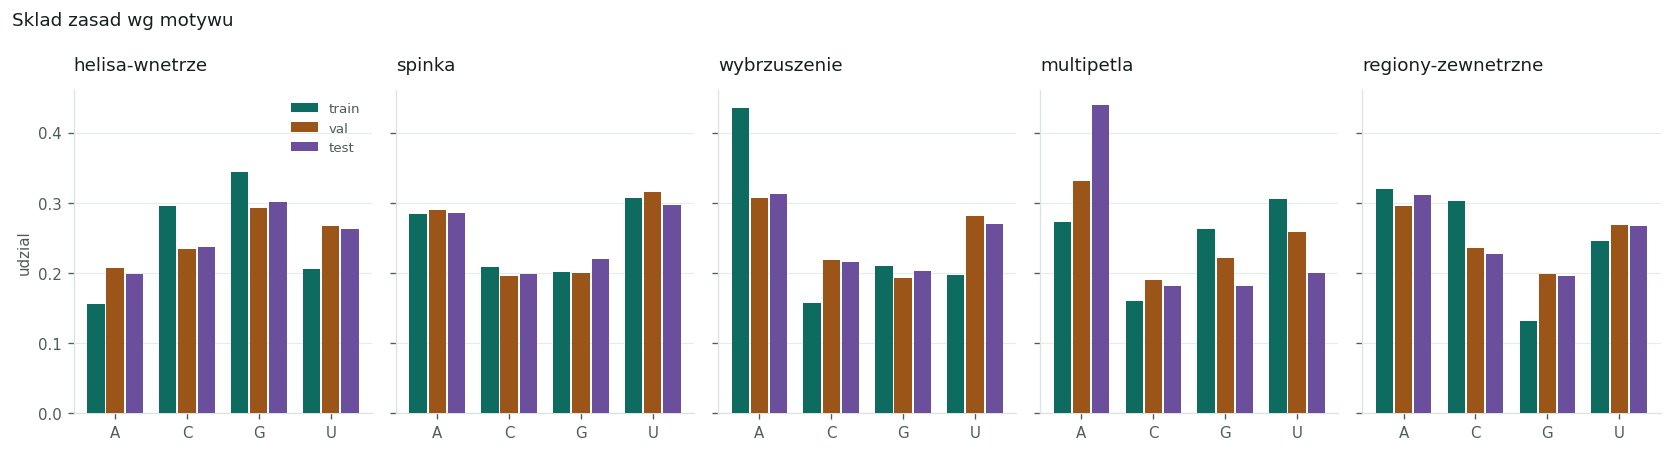

In [5]:
zrodla = [(z, czesci[z]) for z in ZBIORY]
kolory_z = [C1, C2, C3]
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]

fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla)
for ax, m in zip(axs, pokaz):
    for k, (nz, d) in enumerate(zrodla):
        c = sklad_motywy(d.secondary_structure, d.sequence)[m]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=kolory_z[k], label=nz if m == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m, "udzial" if m == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad zasad wg motywu",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 4. Typy par

Pary chwiejne G:U sa slabsze energetycznie, ale w naturze wystepuja regularnie. To wielkosc czula na
degeneracje: model dazacy wylacznie do stabilnosci zastepuje wszystko parami G:C.

train                 G:C 0.600  A:U 0.297  G:U 0.103
val                   G:C 0.484  A:U 0.386  G:U 0.130
test                  G:C 0.484  A:U 0.371  G:U 0.145


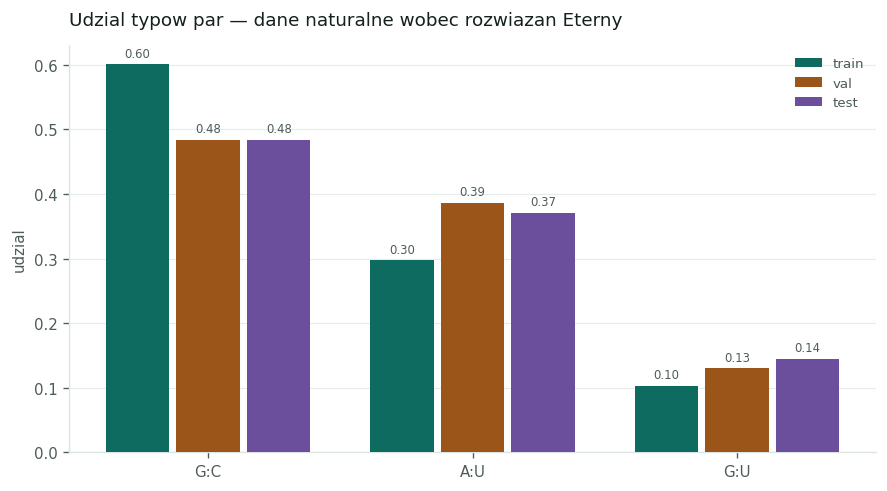

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(3)
w = 0.8 / len(zrodla)
for k, (nz, d) in enumerate(zrodla):
    t = typy_par(d.secondary_structure, d.sequence)
    tot = sum(t.values()) or 1
    v = [t[g] / tot for g in ("G:C", "A:U", "G:U")]
    b = ax.bar(x + (k - (len(zrodla) - 1) / 2) * w, v, w * 0.9, color=kolory_z[k], label=nz, zorder=3)
    for r, vv in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, vv + 0.012, f"{vv:.2f}",
                ha="center", fontsize=7, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
styl(ax, "Udzial typow par — dane naturalne wobec rozwiazan Eterny", "udzial")
ax.legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.tight_layout()

for nz, d in zrodla:
    t = typy_par(d.secondary_structure, d.sequence)
    tot = sum(t.values()) or 1
    print(f"{nz:22}" + "  ".join(f"{k} {t[k] / tot:.3f}" for k in ("G:C", "A:U", "G:U")))

## 5. Przesuniecie skladu miedzy zbiorami — czy trening w ogole przypomina test?

Podzial rodzinowy gwarantuje, ze test sklada sie z rodzin niewidzianych w treningu. Ale ma to skutek
uboczny, o ktory trzeba zapytac wprost: **czy zbior treningowy ma taki sam sklad nukleotydowy jak
test?** Jesli nie, model nauczy sie rozkladu, ktory na tescie jest po prostu zly — niezaleznie od
architektury i funkcji straty.

Ponizej trzy poziomy: caly lancuch, same pozycje niesparowane oraz typy par. Ostatni panel pokazuje
roznice train minus test w punktach procentowych.

ROZNICA TRAIN wobec TEST (punkty procentowe)

  Cala sekwencja                A  -1.53   C  +2.57   G  +1.98   U  -3.03      najwieksza: U -3.03 pp
  Pozycje niesparowane (petle)  A  +0.72   C  -1.39   G  +0.25   U  +0.42      najwieksza: C -1.39 pp
  Typy par                      G:C +11.64   A:U  -7.41   G:U  -4.23      najwieksza: G:C +11.64 pp

UDZIAL PAR G:C — czego model sie uczy, a czego od niego oczekujemy
  train   0.600
  val     0.484
  test    0.484

Z CZEGO SKLADA SIE KAZDY PODZBIOR (cztery najwieksze rodziny)
  train   tRNA 64%,  5S 29%,  mir-9 1%,  mir-124 1%
  val     16S 31%,  U2 4%,  SSU_rRNA_bacteria 3%,  U1 2%
  test    SRP 14%,  RNaseP 8%,  Cobalamin 3%,  ctRNA_pND324 3%


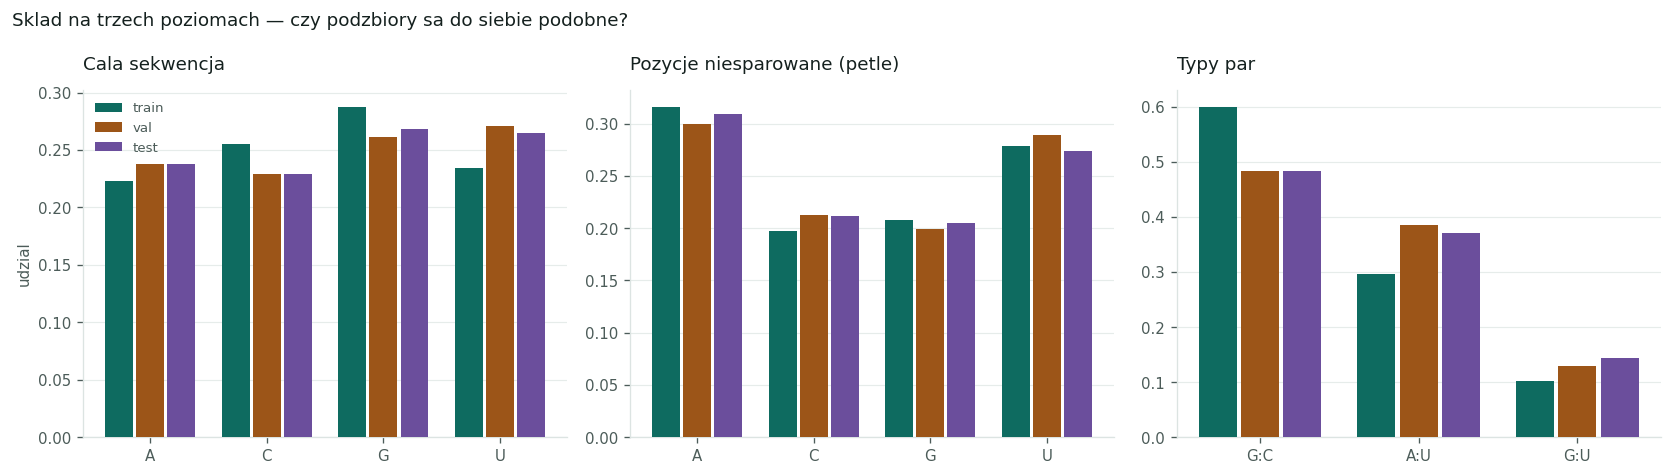

In [7]:
# Sklad na trzech poziomach, dla kazdego podzbioru osobno.
def sklad_trzy(df):
    """Zwraca (sklad calej sekwencji, sklad petli, udzialy typow par)."""
    cala, petle, typy = Counter(), Counter(), Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(df.secondary_structure, df.sequence):
        st, sq = str(st), str(sq)
        pary = parse_pairs(st)
        sparowane = {k for p in pary for k in p}
        cala.update(sq)
        petle.update(sq[k] for k in range(len(sq)) if k not in sparowane)
        for i, j in pary:
            for nazwa, g in grupy.items():
                if sq[i] + sq[j] in g:
                    typy[nazwa] += 1
    n1, n2, n3 = (sum(x.values()) or 1 for x in (cala, petle, typy))
    return ({b: cala[b] / n1 for b in BASES},
            {b: petle[b] / n2 for b in BASES},
            {k: typy[k] / n3 for k in ("G:C", "A:U", "G:U")})


S = {z: sklad_trzy(czesci[z]) for z in ZBIORY}
ZR = list(ZBIORY)
POZIOMY = [(0, "Cala sekwencja", BASES),
           (1, "Pozycje niesparowane (petle)", BASES),
           (2, "Typy par", ["G:C", "A:U", "G:U"])]

fig, axs = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, (k, tytul, klasy) in zip(axs, POZIOMY):
    x = np.arange(len(klasy))
    w = 0.8 / len(ZR)
    for n, (z, kol) in enumerate(zip(ZR, (C1, C2, C3, C4))):
        v = [S[z][k][c] for c in klasy]
        ax.bar(x + (n - (len(ZR) - 1) / 2) * w, v, w * 0.9, color=kol,
               label=z if k == 0 else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(klasy, fontsize=10)
    styl(ax, tytul, "udzial" if k == 0 else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad na trzech poziomach — czy podzbiory sa do siebie podobne?",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

print("ROZNICA TRAIN wobec TEST (punkty procentowe)")
print()
for k, tytul, klasy in POZIOMY:
    r = {c: 100 * (S["train"][k][c] - S["test"][k][c]) for c in klasy}
    najw = max(r, key=lambda c: abs(r[c]))
    print(f"  {tytul:<30}" + "   ".join(f"{c} {r[c]:+6.2f}" for c in klasy)
          + f"      najwieksza: {najw} {r[najw]:+.2f} pp")

print()
print("UDZIAL PAR G:C — czego model sie uczy, a czego od niego oczekujemy")
for z in ZBIORY:
    print(f"  {z:<8}{S[z][2]['G:C']:.3f}")

print()
print("Z CZEGO SKLADA SIE KAZDY PODZBIOR (cztery najwieksze rodziny)")
for z in ZBIORY:
    vc = czesci[z].family.value_counts().head(4)
    print(f"  {z:<8}" + ",  ".join(f"{k} {100 * v / len(czesci[z]):.0f}%"
                                   for k, v in vc.items()))
